# Exploratory Data Analysis

In [7]:
import pandas as pd
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import numpy as np
import cv2
import random
import sys
import os
import hashlib
from collections import defaultdict

sys.path.append(os.path.abspath(".."))
from Config import constants
from src.utils import get_subplot_dims

In [8]:
dataset_path = constants.RAW_DATA_DIR

## Dataset Overview

In [9]:
# Count images per class
class_counts = Counter()
for class_dir in Path(dataset_path).iterdir():
    if class_dir.is_dir():
        count = len(list(class_dir.glob("*.ppm")))
        class_counts[class_dir.name] = count

print(f"Total classes: {len(class_counts)}")
print(f"Total images: {sum(class_counts.values())}")
#print(class_counts)

Total classes: 43
Total images: 26640


## Class Distribution

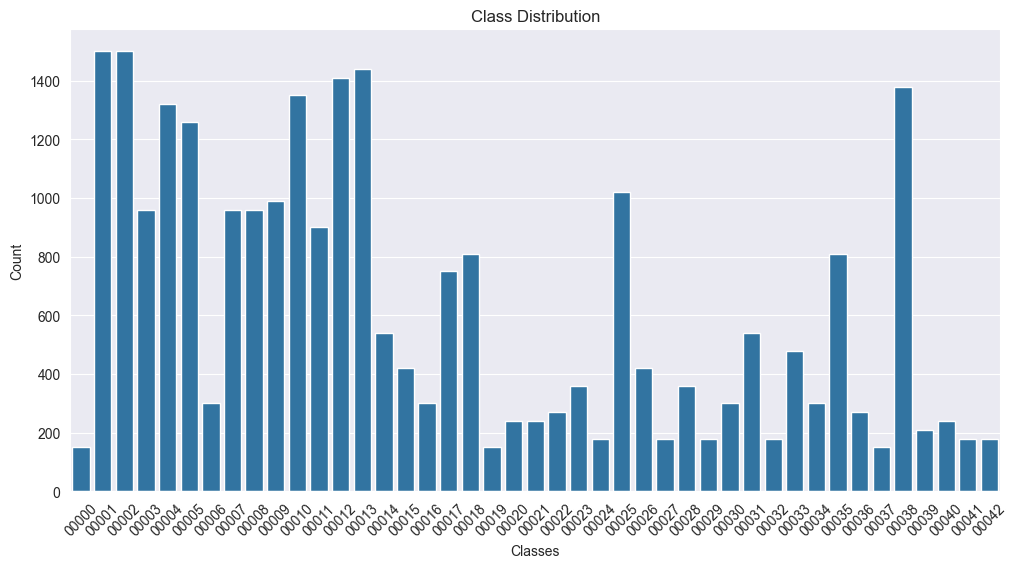

In [10]:
df_counts = pd.DataFrame({
    "class": class_counts.keys(),
    "count": class_counts.values(),
})

plt.figure(figsize=(12, 6))
sns.barplot(x="class", y="count", data=df_counts)
plt.xticks(rotation=45)
plt.xlabel("Classes"), plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

## Image Dimensions & Aspect Ratios

In [11]:
widths, heights = [], []

for img_path in Path(dataset_path).rglob("*.ppm"):
    with Image.open(img_path) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)

Width  — min: 25, max: 243, mean: 51
Height — min: 25, max: 225, mean: 50


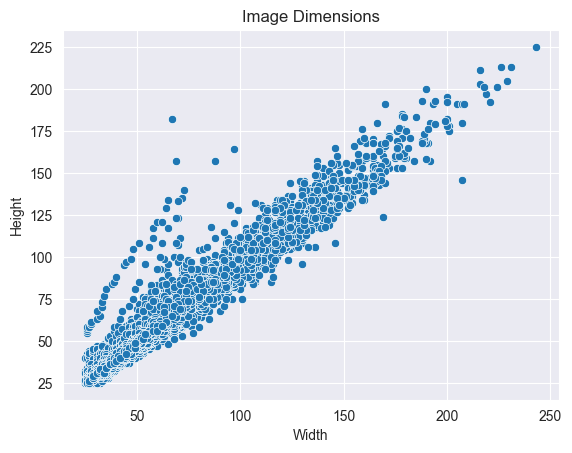

In [12]:
print(f"Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}")
print(f"Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}")

df_wh = pd.DataFrame({
    "width": widths,
    "height": heights,
})

# plt.scatter(widths, heights, alpha=0.3)
sns.scatterplot(x="width", y="height", data=df_wh)
plt.xlabel("Width"), plt.ylabel("Height")
plt.title("Image Dimensions")
plt.show()

## Color Analysis

In [13]:
mean_brightness = []

for img_path in Path(dataset_path).rglob("*.ppm"):
    img = cv2.imread(str(img_path))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    mean_brightness.append(gray.mean())


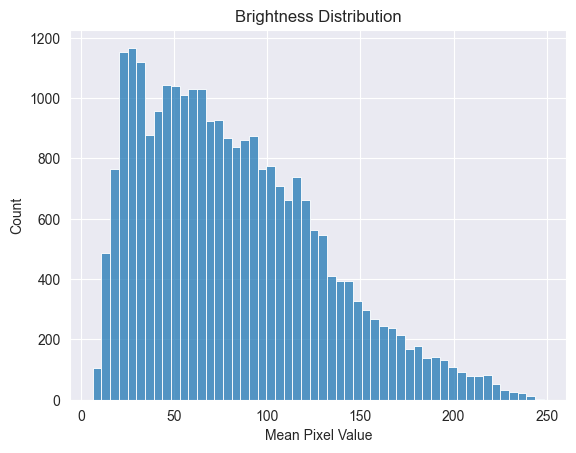

In [14]:
#plt.hist(mean_brightness, bins=50)
sns.histplot(mean_brightness)
plt.title("Brightness Distribution")
plt.xlabel("Mean Pixel Value")
plt.show()

## Sample Grid Visualization

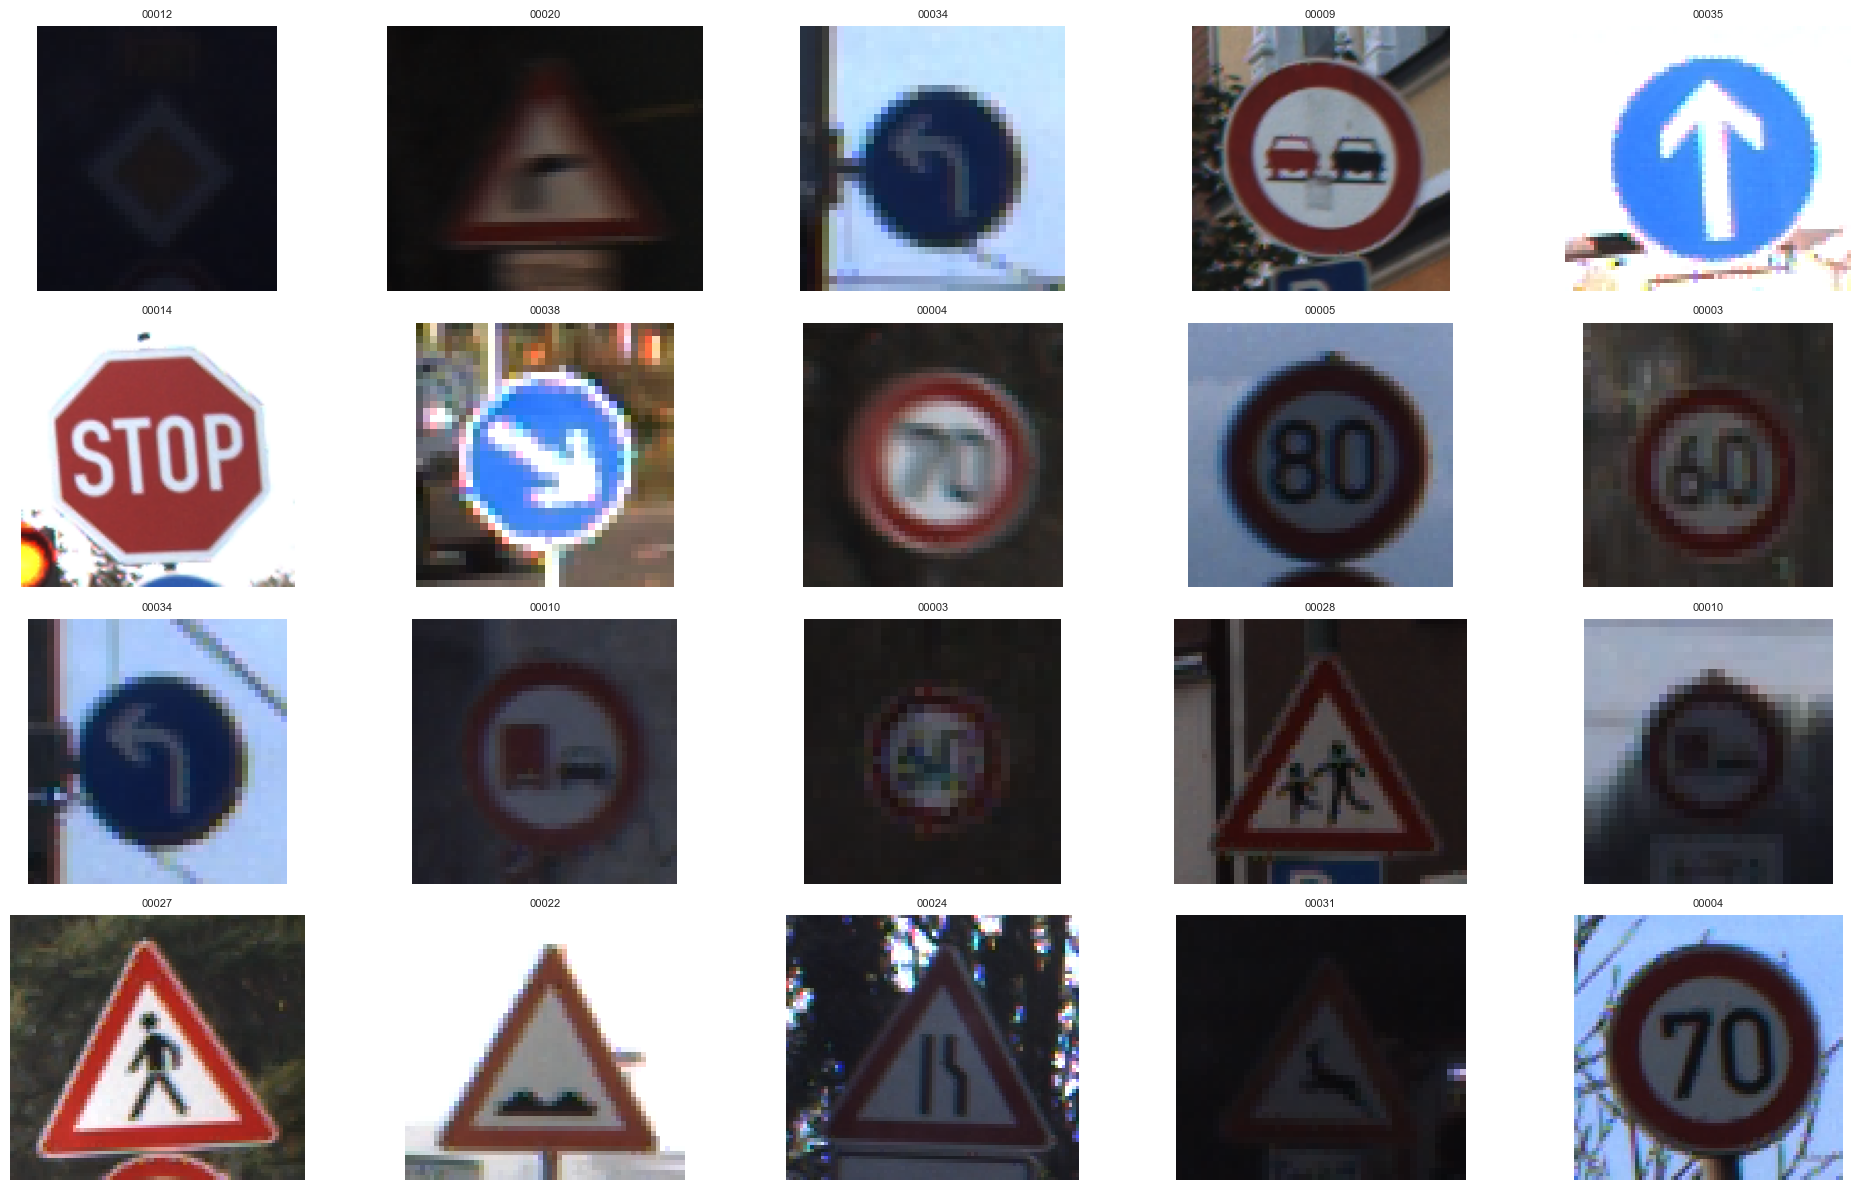

In [15]:
all_images = list(Path(dataset_path).rglob("*.ppm"))
samples = random.sample(all_images, constants.RANDOM_SAMPLE_SIZE)

nrows, ncols, figsize = get_subplot_dims(constants.RANDOM_SAMPLE_SIZE)
fig, axes = plt.subplots(nrows, ncols, figsize=figsize)

for ax, img_path in zip(axes.flat, samples):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(img_path.parent.name, fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Corrupt or Unreadable Files

In [16]:
corrupt = []
for img_path in Path(dataset_path).rglob("*.jpg"):
    try:
        Image.open(img_path).verify()
    except Exception:
        corrupt.append(img_path)

print(f"Corrupt images: {len(corrupt)}")

Corrupt images: 0


## Duplicate Detection

In [17]:
hashes = defaultdict(list)
for img_path in Path(dataset_path).rglob("*.jpg"):
    h = hashlib.md5(img_path.read_bytes()).hexdigest()
    hashes[h].append(img_path)

duplicates = {k: v for k, v in hashes.items() if len(v) > 1}
print(f"Duplicate groups: {len(duplicates)}")

Duplicate groups: 0


## Key Metrics

In [18]:
# class balance
max_count = max(class_counts.values())
min_count = min(class_counts.values())
average_count = np.mean(list(class_counts.values()))
median_count = np.median(list(class_counts.values()))
imbalance_ratio = max_count / min_count

In [19]:
# image sizes
min_widths = min(widths)
max_widths = max(widths)
mean_widths = np.mean(widths)
median_widths = np.median(widths)
min_heights = min(heights)
max_heights = max(heights)
mean_heights = np.mean(heights)
median_heights = np.median(heights)

In [20]:
# brightness
mean_brightness_min = min(mean_brightness)
mean_brightness_max = max(mean_brightness)
mean_brightness_mean = np.mean(mean_brightness)
mean_brightness_median = np.mean(mean_brightness)

In [21]:
# corrupted files
num_corrupt = len(corrupt)

In [22]:
# duplicate files
num_duplicates = len(duplicates)

In [23]:
# aspect ratios
aspect_ratios = [w/h for w, h in zip(widths, heights)]

min_aspect_ratio = min(aspect_ratios)
max_aspect_ratio = max(aspect_ratios)
average_aspect_ratio = np.mean(aspect_ratios)
median_aspect_ratio = np.median(aspect_ratios)

In [24]:
metrics = {
    "Class balance": [max_count, min_count, average_count, median_count, imbalance_ratio],
    "Image width": [min_widths, max_widths, mean_widths, median_widths, ""],
    "Image height": [min_heights, max_heights, mean_heights, median_heights, ""],
    "Brightness": [mean_brightness_min, mean_brightness_max, mean_brightness_mean, mean_brightness_median, ""],
    "Aspect ratio": [min_aspect_ratio, max_aspect_ratio, average_aspect_ratio, median_aspect_ratio, ""],
    "Corrupted files": [num_corrupt, "", "", "", ""],
    "Duplicate files": [num_duplicates, "", "", "", ""],

}

index = ["Min", "Max", "Mean", "Median", "Imbalance/Count"]

df = pd.DataFrame(metrics, index=index)
display(df)

,Class balance,Image width,Image height,Brightness,Aspect ratio,Corrupted files,Duplicate files
Min,1500.000000,25,25,6.202023,0.368132,0,0
Max,150.000000,243,225,248.440009,1.417808,,
Mean,619.534884,50.933784,50.365128,82.185355,1.008718,,
Median,420.000000,43.0,43.0,82.185355,1.0,,
Imbalance/Count,10.000000,,,,,,
